# Retail Store Staff Scheduling


# 1 - Abstract

The retail staff scheduling problem aims to develop an optimal schedule for a month (21 bussines day period), ensuring efficient utilization of seven contracted workers with varying skill levels and availability. The goal is to meet daily staffing requirements while minimizing labor costs and promoting fairness in workload distribution. This problem involves assigning workers to shifts in a way that meets operational needs, including the presence of supervisors on specified days, and adheres to constraints such as workers' availability and weekly hour limits to avoid overtime.

The methodology used is integer linear programming, which optimizes the assignment of workers to shifts while considering their availability, skill levels, and the necessity to have at least one supervisor on certain days. The solver provided feasible solutions that minimize total salary costs and ensure a fair distribution of work among the employees.

The results demonstrate that the optimization model can successfully create a balanced schedule that reduces labor costs and distributes the workload equitably among workers. This approach ensures that all workers are utilized effectively, operational requirements are met, and the risk of employee burnout is minimized, contributing to the overall efficiency and productivity of the retail store.


# 2 - Problem Statement

The objective is to develop an optimal staff schedule for a retail store over a 21-day period using integer linear programming. The retail store employs 7 workers with varying skill levels, including general and supervisory skills. The scheduling must ensure that daily staffing requirements are met, while also accommodating workers' availability and minimizing the total cost associated with salaries and potential overtime.

The workforce plan should consider varying resource requirements on different days, with some days requiring supervisory skills. Additionally, the schedule must balance the workload among workers to promote fairness, ensuring that all workers are utilized efficiently and no one is overburdened.

By optimizing the staff schedule, the retail store aims to streamline operations, minimize labor costs, and ensure fair distribution of work. This includes adhering to constraints such as workers' availability, the necessity of having at least one supervisor on certain days, and compliance with weekly hour limits to avoid excessive overtime.

The problem involves:
- Assigning workers to shifts in a way that meets daily shift limits.
- Ensuring at least one supervisor is present on specified days.
- Avoiding assigning more than three consecutive days of work to any worker.
- Complying with operational constraints such as availability and weekly hour limits.


# 3 - System

### 3.1 - Agents/Decision Makers (DMs)
**Store Manager**: The primary decision-maker responsible for workforce planning and scheduling in the retail store.
- **Attributes/Characteristics**: Experience level, decision-making preferences, availability, cost considerations, fairness considerations.
- **Objectives**: Minimize the total cost, balance workload among employed workers..

### 3.2 - Entities
**Retail Workers**: Employees working in the retail store who possess different levels of skills and exhibit identical productivity levels within the same skill level.
- **Attributes/Characteristics**: Availability, skill level, productivity, work preferences, work hour restrictions.
- **Salaries**: The daily salaries of the workers, which vary.
- **Availability**: The days each worker is not available to work.
- **Skills**: The skill levels of the workers, which include general and supervisor.

### 3.3 - Relationships among elements
**Worker-Shift Assignment**: The relationship between retail workers and shifts in the schedule.
- **Attributes/Characteristics**: Worker availability, shift requirements, assigned shifts, workload distribution, shift preferences, fairness considerations.
- **Constraints**:
  - Workers can only be assigned to shifts if they are available.
  - Shifts must meet resource requirements.
  - Workload should be balanced among workers.
  - Supervisors must be assigned to certain shifts.


# 4 - Data




**List the data sources**

- $\text{days} \in \mathbb{D}$: This parameter represents the set of days over which the scheduling is performed.

- $\text{workers} \in \mathbb{W}$: This parameter represents the set of workers available for scheduling.

- $\text{shift_limit}(d) \in \mathbb{N}$: This parameter represents the number of workers required on each day $d \in \text{days}$.

- $\text{salary}(w) \in \mathbb{R}^{+}$: This parameter is the salary per day of each worker $w \in \text{workers}$.

- $\text{supervisor_days} \in \mathbb{D}$: This set represents the days on which a supervisor is required.

- $\text{supervisors} \in \mathbb{W}$: This set represents the workers who can serve as supervisors.

- $\text{not_available} = {(w,d) : w \in \text{workers} \text{ is not available on day } d \in \text{days}}$: This binary variable indicates if a worker $w$ is not available on a given day $d$.

- $\text{weekly_hours_limit} \in \mathbb{R}^{+}$: This parameter represents the maximum number of hours a worker can work in a week before overtime kicks in.
$\text{hours_per_shift} \in \mathbb{R}^{+}$: This parameter represents the number of hours in each shift.


**Assumption:**
- Workers have a weekly hours limit beyond which they are paid overtime.
\begin{equation}
\forall \text{week} \in \text{weeks}, \forall w \in \text{workers}: \sum_{d \in \text{week}} \text{x}[w, d] \times \text{hours_per_shift} \leq \text{weekly_hours_limit}
\end{equation}

- Supervisors are required on specific days, and only workers who are supervisors can be assigned to those days.
\begin{equation}
\forall d \in \text{supervisor_days}: \sum_{w \in \text{supervisors}} \text{x}[w, d] \geq 1
\end{equation}


# 5 - The Scenarios





## 5.1 - Mathematical model
*Use this subsection to present the code of the main mathematical model for the considered problem*

### 5.1.1 - Preliminary operations
*Comment the code in the next cell that performs the preliminary operations:*

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
working_in_colab = True # If not working in colab False, otherwise True

if working_in_colab:
    !pip install pandas
    !pip install -q pyomo              # Quiet installation of pyomo using pip.
    !apt-get install -y -qq coinor-cbc # Installation of COIN-OR CBC slover.
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)   # Connect your drive

Mounted at /content/drive


In [21]:
if working_in_colab:
    input_directory = "/content/drive/MyDrive/MDMM" #change link to the source of the data
    output_directory = "/content/drive/MyDrive/MDMM/Output/Output"
    cbc_path = "/usr/bin/cbc"
else:
    input_directory = "./Input/"
    output_directory = "./Output/"
    cbc_path = "C:/Program Files/Cbc/bin/cbc.exe" # write the path of the cbc.exe file on your pc

In [22]:
import pyomo.environ as pyo
from pyomo.opt import SolverFactory
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import pandas as pd


# Load data from JSON file
with open('/content/drive/MyDrive/MDMM/new submission/Data.json', 'r') as f:
    data = json.load(f)


### 5.1.2 - Sets

- $\text {days}$: Set of days over which the scheduling is done.

- $\text {workers}$: Set of workers along with their availability, salary, and skill level.

In [23]:
# Create a model
model = pyo.ConcreteModel()

# Define the Sets and Parameters
days = data['days']
workers = data['workers']
shift_limits = data['shift_limits']
salaries = data['salaries']
supervisor_days = data['supervisor_days']
supervisors = data['supervisors']
not_available = data['not_available']
weekly_hours_limit = data['weekly_hours_limit']
hours_per_shift = data['hours_per_shift']

# Initialize sets
model.days = pyo.Set(initialize=days)
model.workers = pyo.Set(initialize=workers)


In [24]:
for key, value in data.items():
    print(f"{key}: {value}\n")

days: ['day1', 'day2', 'day3', 'day4', 'day5', 'day6', 'day7', 'day8', 'day9', 'day10', 'day11', 'day12', 'day13', 'day14', 'day15', 'day16', 'day17', 'day18', 'day19', 'day20', 'day21']

workers: ['worker_1', 'worker_2', 'worker_3', 'worker_4', 'worker_5', 'worker_6', 'worker_7']

shift_limits: {'day1': 2, 'day2': 2, 'day3': 2, 'day4': 2, 'day5': 2, 'day6': 4, 'day7': 4, 'day8': 2, 'day9': 2, 'day10': 2, 'day11': 2, 'day12': 4, 'day13': 4, 'day14': 2, 'day15': 2, 'day16': 2, 'day17': 4, 'day18': 4, 'day19': 2, 'day20': 2, 'day21': 2}

salaries: {'worker_1': 20, 'worker_2': 18, 'worker_3': 15, 'worker_4': 12, 'worker_5': 10, 'worker_6': 17, 'worker_7': 10}

supervisor_days: ['day6', 'day7', 'day12', 'day13', 'day17', 'day18']

supervisors: ['worker_1', 'worker_2', 'worker_3']

not_available: {'worker_1': ['day13', 'day14'], 'worker_2': ['day9', 'day10'], 'worker_3': ['day16', 'day17'], 'worker_4': ['day1', 'day2', 'day3'], 'worker_5': ['day4', 'day5', 'day6'], 'worker_6': ['day7', 'day

### 5.1.3 - Parameters
*Comment the code in the next cell that reads the data described in Section 5 and defines the dictionaries and/or frames used in the model.*

**Parameters:**

- $\text {shift_limits}$: Dictionary specifying the number of workers required each day.

- $\text {salaries}$: Dictionary specifying the salary for each worker.

- $\text {not_available}$: Dictionary specifying the days each worker is not available.
          


In [25]:
# Initialize parameters
model.shift_limit = pyo.Param(model.days, initialize=shift_limits)
model.salary = pyo.Param(model.workers, initialize=salaries)
model.availability = pyo.Param(model.workers, model.days, initialize=lambda model, w, d: 0 if d in not_available[w] else 1)


In [26]:
# Printing shift limit
print("Shift Limits:")
for day in model.days:
    print(f"Day {day}: {model.shift_limit[day]}")

# Printing salaries
print("\nSalaries:")
for worker in model.workers:
    print(f"Worker {worker}: {model.salary[worker]}")

# Printing availability
print("\nAvailability:")
for worker in model.workers:
    for day in model.days:
        print(f"Worker {worker}, Day {day}: {'Available' if model.availability[worker, day] == 1 else 'Not Available'}")


Shift Limits:
Day day1: 2
Day day2: 2
Day day3: 2
Day day4: 2
Day day5: 2
Day day6: 4
Day day7: 4
Day day8: 2
Day day9: 2
Day day10: 2
Day day11: 2
Day day12: 4
Day day13: 4
Day day14: 2
Day day15: 2
Day day16: 2
Day day17: 4
Day day18: 4
Day day19: 2
Day day20: 2
Day day21: 2

Salaries:
Worker worker_1: 20
Worker worker_2: 18
Worker worker_3: 15
Worker worker_4: 12
Worker worker_5: 10
Worker worker_6: 17
Worker worker_7: 10

Availability:
Worker worker_1, Day day1: Available
Worker worker_1, Day day2: Available
Worker worker_1, Day day3: Available
Worker worker_1, Day day4: Available
Worker worker_1, Day day5: Available
Worker worker_1, Day day6: Available
Worker worker_1, Day day7: Available
Worker worker_1, Day day8: Available
Worker worker_1, Day day9: Available
Worker worker_1, Day day10: Available
Worker worker_1, Day day11: Available
Worker worker_1, Day day12: Available
Worker worker_1, Day day13: Not Available
Worker worker_1, Day day14: Not Available
Worker worker_1, Day day1

### 5.1.4 - Variables

**Variables:**

- $ \text{model.x} $: Binary decision variable representing whether a worker is assigned to a shift on a specific day.
    1. $ \text{model.x}[w, d] = 1 $ if worker $ w $ is assigned to day $ d $.
    2. $ \text{model.x}[w, d] = 0 $ if worker $ w $ is not assigned to day $ d $.

- $ \text{model.tot_days} $: Non-negative integer decision variable representing the total number of days each worker is assigned to work.

    1. $ \text{model.tot_days}[w] $ indicates the total number of days worker $ w $ is assigned to work over the entire scheduling period.


- $ \text{model.max_days} $: Non-negative integer variable representing the maximum number of days worked by any worker.

- $ \text{model.min_days} $: Non-negative integer variable representing the minimum number of days worked by any worker.


In [27]:
# Decision variables
model.x = pyo.Var(model.workers, model.days, domain=pyo.Binary)
model.tot_days = pyo.Var(model.workers, within=pyo.NonNegativeIntegers)

# Auxiliary variables for fairness
model.max_days = pyo.Var(within=pyo.NonNegativeIntegers)
model.min_days = pyo.Var(within=pyo.NonNegativeIntegers)

## 5.2 - Constraints and Objective(s) Scenario 1
*Comment the code in the next cell that defines the objectives and the constraints of the model.*<br>

### Objective Function

- **Objective:** This objective function minimizes the total cost by summing up the product of the total days worked by each worker and their respective salary.

\begin{equation}
\text{minimize} \sum_{w \in \text{workers}} \text{tot_days}[w] \times \text{salary}[w]
\end{equation}

### Constraints

- **Shift Requirements:**  This constraint ensures that the required number of workers are assigned to each day.

\begin{equation}
\sum_{w \in \text{workers}} \text{model.x}[w, d] = \text{shift_limit}[d], \quad \forall d \in \text{days}
\end{equation}


- **Worker Availability:** This constraint ensures that a worker is only assigned to a day if they are available.

\begin{align*}
\text{model.x}[w, d] \leq \text{availability}[w, d], \quad \forall w \in \text{workers}, \forall d \in \text{days}
\end{align*}


- **Supervisor Requirement:** This constraint ensures that at least one supervisor is assigned to the days requiring supervision.

\begin{equation}
\sum_{w \in \text{supervisors}} \text{model.x}[w, d] = 1, \quad \forall d \in \text{supervisor_days}
\end{equation}


- **Update Total Days Worked:** This constraint updates the total days worked by each worker.

\begin{equation}
\text{tot_days}[w] = \sum_{d \in \text{days}} \text{model.x}[w, d], \quad \forall w \in \text{workers}
\end{equation}


- **Minimum Work Days Constraint:** This constraint ensures that each worker works at least a minimum number of days (5 days).

\begin{equation}
\text{tot_days}[w] \geq 5, \quad \forall w \in \text{workers}
\end{equation}


- **Consecutive Days Constraint:** This constraint ensures that a worker does not work more than 3 consecutive days.

\begin{equation}
\sum_{j=i}^{i+3} \text{model.x}[w, \text{days}[j]] \leq 3, \quad \forall w \in \text{workers}, \forall i \in \{0, \ldots, |\text{days}| - 4\}
\end{equation}


- **Weekly Hours Limit Constraint:** This constraint ensures that the total hours worked by any worker in a week does not exceed the weekly hours limit.

\begin{equation}
\sum_{d \in \text{week_days}} \text{model.x}[w, d] \times \text{hours_per_shift} \leq \text{weekly_hours_limit}, \quad \forall w \in \text{workers}, \forall \text{week_start} \in \{0, 5, 10, \ldots\}
\end{equation}

In [28]:

# Objective function: Minimize total cost
model.objective = pyo.Objective(
    expr=sum(model.tot_days[w] * model.salary[w] for w in model.workers),
    sense=pyo.minimize
)

# Constraints

# Max cost
model.cost_constraint = pyo.Constraint(
    expr=sum(model.tot_days[w] * model.salary[w] for w in model.workers) <= 800
)

# Shift requirements
model.shift_requirements = pyo.ConstraintList()
for d in model.days:
    model.shift_requirements.add(sum(model.x[w, d] for w in model.workers) == model.shift_limit[d])

# Worker availability
model.worker_availability_constraint = pyo.Constraint(
    model.workers, model.days,
    rule=lambda model, w, d: model.x[w, d] <= model.availability[w, d]
)

# Supervisor requirement
model.supervisor_requirements = pyo.ConstraintList()
for d in supervisor_days:
    model.supervisor_requirements.add(sum(model.x[w, d] for w in supervisors) >= 1)

# Update total days worked
model.tot_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.tot_days[w] == sum(model.x[w, d] for d in model.days)
)

# Minimum work days constraint
min_work_days = 5  # Minimum number of days each worker should work
model.min_work_days_constraint = pyo.ConstraintList()
for w in model.workers:
    model.min_work_days_constraint.add(model.tot_days[w] >= min_work_days)

# Add the consecutive days constraint
model.consecutive_days = pyo.ConstraintList()
for w in model.workers:
    for i in range(len(model.days) - 3):
        model.consecutive_days.add(sum(model.x[w, days[j]] for j in range(i, i + 4)) <= 3)


# Add the weekly hours limit constraint
model.weekly_hours_constraint = pyo.ConstraintList()
for w in model.workers:
    for week_start in range(0, len(model.days), 5):
        week_days = days[week_start:week_start+5]
        model.weekly_hours_constraint.add(
            sum(model.x[w, d] for d in week_days) * hours_per_shift <= weekly_hours_limit
        )


# This constrainat is really cool, it just make worker_5 and worker_7 not work on the same day
model.new_constraint = pyo.ConstraintList()
for d in model.days:
    model.new_constraint.add(model.x['worker_5', d] + model.x['worker_7', d] <= 1)




### 5.2.1 - Model solution
*Comment the code in the next cell that calls the functions that solve the model and stores the values of the variables.*

In [29]:
# Solve the model using the CBC solver
solver = SolverFactory('cbc')
results = solver.solve(model)

# Check results and print
if results.solver.status == pyo.SolverStatus.ok and results.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Solver terminated successfully with an optimal solution.")
    print("Total cost:", pyo.value(model.objective))
    for w in model.workers:
        print(f"{w}: Total days worked = {pyo.value(model.tot_days[w])}")
else:
    print("Solver did not find an optimal solution.")
    if results.solver.termination_condition == pyo.TerminationCondition.infeasible:
        print("Model is infeasible.")
        for d in model.days:
            available_workers = sum(1 for w in model.workers if model.availability[w, d] == 1)
            print(f"{d}: Shift limit = {shift_limits[d]}, Available workers = {available_workers}")


Solver terminated successfully with an optimal solution.
Total cost: 716.0
worker_1: Total days worked = 5.0
worker_2: Total days worked = 5.0
worker_3: Total days worked = 5.0
worker_4: Total days worked = 13.0
worker_5: Total days worked = 8.0
worker_6: Total days worked = 5.0
worker_7: Total days worked = 13.0


### 5.2.2 - Analysis
*Comment the model solutions and their possible applications in the real world with respect to different scenarios.*


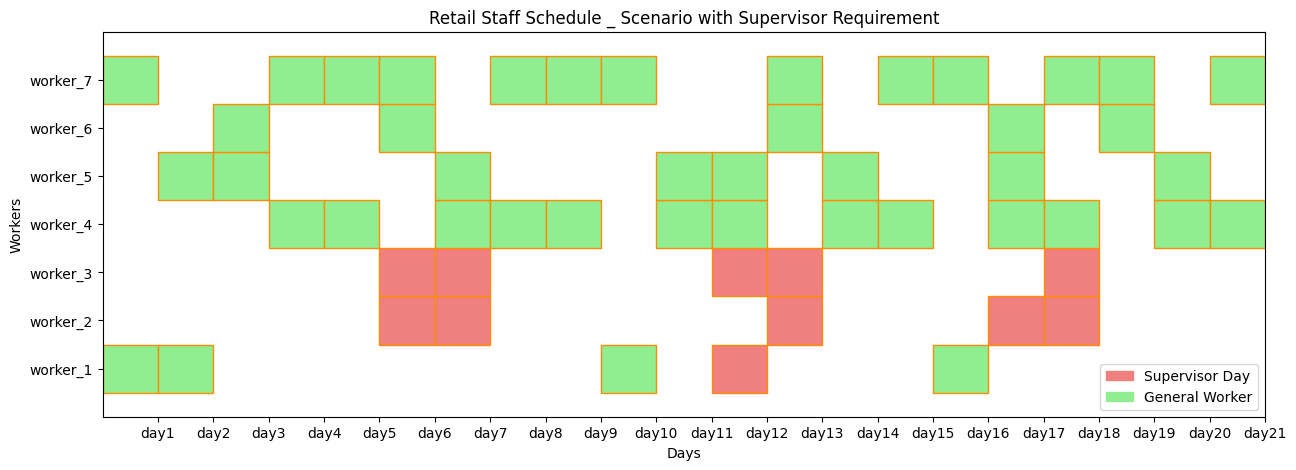


Worker Summary:
  Worker  Total Days Worked                                                                        Assigned Days
worker_1                5.0                                                      day1, day2, day10, day12, day16
worker_2                5.0                                                      day6, day7, day13, day17, day18
worker_3                5.0                                                      day6, day7, day12, day13, day18
worker_4               13.0 day4, day5, day7, day8, day9, day11, day12, day14, day15, day17, day18, day20, day21
worker_5                8.0                                  day2, day3, day7, day11, day12, day14, day17, day20
worker_6                5.0                                                      day3, day6, day13, day17, day19
worker_7               13.0  day1, day4, day5, day6, day8, day9, day10, day13, day15, day16, day18, day19, day21

Supervisor Shifts:
  Day Supervisor
 day6   worker_3
 day7   worker_3
day12   

In [30]:
# Generating the Gantt chart
def generate_gantt_diagram(model, workers, shifts, supervisor_days, buffer):
    fig, ax = plt.subplots(figsize=(15, 5))

    # Set y-axis limits
    ax.set_ylim(0, len(workers) + 1)
    ax.set_yticks(range(1, len(workers) + 1))
    ax.set_yticklabels(workers)

    # Set x-axis limits
    ax.set_xlim(0, len(shifts))
    ax.set_xticks(range(1, len(shifts) + 1))
    ax.set_xticklabels(shifts)

    # Plot worker shifts
    for i, worker in enumerate(workers, start=1):
        for j, day in enumerate(shifts):
            if model.x[worker, day].value == 1:
                facecolor = 'lightgreen'
                if day in supervisor_days and worker in supervisors:
                    facecolor = 'lightcoral'
                rect = mpatches.Rectangle((j, i - 0.5), 1, 1, facecolor=facecolor, edgecolor='darkorange')
                ax.add_patch(rect)

    # Add legend
    supervisor_patch = mpatches.Patch(color='lightcoral', label='Supervisor Day')
    general_worker_patch = mpatches.Patch(color='lightgreen', label='General Worker')
    ax.legend(handles=[supervisor_patch, general_worker_patch])

    # Set labels and title
    ax.set_xlabel('Days')
    ax.set_ylabel('Workers')
    ax.set_title('Retail Staff Schedule _ Scenario with Supervisor Requirement')

    # Save the Gantt chart as an image file
    plt.savefig(buffer, bbox_inches='tight')
    # Show the chart
    plt.show()

generate_gantt_diagram(model, workers, days, supervisor_days, 'retail_staff_schedule_scenario_with_supervisor_requirement.png')

# Generate summary report
def generate_summary_report(model, workers, days, supervisors, supervisor_days):
    summary = {
        "total_cost": pyo.value(model.objective),
        "worker_details": {},
        "supervisor_shifts": {}
    }

    for w in workers:
        total_days_worked = pyo.value(model.tot_days[w])
        assigned_days = [d for d in days if pyo.value(model.x[w, d]) == 1]
        summary["worker_details"][w] = {
            "total_days_worked": total_days_worked,
            "assigned_days": assigned_days
        }

    for d in supervisor_days:
        for w in supervisors:
            if pyo.value(model.x[w, d]) == 1:
                summary["supervisor_shifts"][d] = w

    return summary

summary_report = generate_summary_report(model, workers, days, supervisors, supervisor_days)

# Create a pandas DataFrame for the summary report
worker_summary = {
    "Worker": [],
    "Total Days Worked": [],
    "Assigned Days": []
}

for w in workers:
    worker_summary["Worker"].append(w)
    worker_summary["Total Days Worked"].append(summary_report["worker_details"][w]["total_days_worked"])
    worker_summary["Assigned Days"].append(", ".join(summary_report["worker_details"][w]["assigned_days"]))

df_worker_summary = pd.DataFrame(worker_summary)

# Supervisor shifts summary
supervisor_summary = {
    "Day": [],
    "Supervisor": []
}

for d, w in summary_report["supervisor_shifts"].items():
    supervisor_summary["Day"].append(d)
    supervisor_summary["Supervisor"].append(w)

df_supervisor_summary = pd.DataFrame(supervisor_summary)

# Display the summaries
print("\nWorker Summary:")
print(df_worker_summary.to_string(index=False))

print("\nSupervisor Shifts:")
print(df_supervisor_summary.to_string(index=False))


## 5.3 - Constraints and Objective(s) Scenario 2

### Objective Function

- **Objective:** This objective function minimizes the difference between the maximum and minimum number of days worked by any worker.
\begin{equation}
\text{minimize} \; (\text{max_days} - \text{min_days})
\end{equation}

### Constraints

- **Shift Requirements:** This constraint ensures that the required number of workers are assigned to each day.

\begin{equation}
\sum_{w \in \text{workers}} \text{model.x}[w, d] = \text{shift_limit}[d], \quad \forall d \in \text{days}
\end{equation}


- **Worker Availability:** This constraint ensures that a worker is only assigned to a day if they are available.

\begin{align*}
\text{model.x}[w, d] \leq \text{availability}[w, d], \quad \forall w \in \text{workers}, \forall d \in \text{days}
\end{align*}


- **Supervisor Requirement:** This constraint ensures that at least one supervisor is assigned to the days requiring supervision.

\begin{equation}
\sum_{w \in \text{supervisors}} \text{model.x}[w, d] \geq 1, \quad \forall d \in \text{supervisor_days}
\end{equation}


- **Update Total Days Worked:** This constraint updates the total days worked by each worker.

\begin{equation}
\text{tot_days}[w] = \sum_{d \in \text{days}} \text{model.x}[w, d], \quad \forall w \in \text{workers}
\end{equation}


- **Minimum Work Days Constraint:** This constraint ensures that each worker works at least a minimum number of days (5 days).

\begin{equation}
\text{tot_days}[w] \geq 5, \quad \forall w \in \text{workers}
\end{equation}

- **Consecutive Days Constraint:** This constraint ensures that a worker does not work more than 3 consecutive days.

\begin{equation}
\sum_{j=i}^{i+3} \text{model.x}[w, \text{days}[j]] \leq 3, \quad \forall w \in \text{workers}, \forall i \in \{0, \ldots, |\text{days}| - 4\}
\end{equation}



- **Weekly Hours Limit Constraint:** This constraint ensures that the total hours worked by any worker in a week does not exceed the weekly hours limit.

\begin{equation}
\sum_{d \in \text{week_days}} \text{model.x}[w, d] \times \text{hours_per_shift} \leq \text{weekly_hours_limit}, \quad \forall w \in \text{workers}, \forall \text{week_start} \in \{0, 5, 10, \ldots\}
\end{equation}


- **Min and Max Days Worked Constraints:** These constraints ensure that the max_days is at least the total days worked by any worker and the min_days is at most the total days worked by any worker.

\begin{equation}
\text{max_days} \geq \text{tot_days}[w], \quad \forall w \in \text{workers}
\end{equation}

\begin{equation}
\text{min_days} \leq \text{tot_days}[w], \quad \forall w \in \text{workers}
\end{equation}


In [31]:
# Objective function: Minimize the difference between max and min days worked
model.objective = pyo.Objective(
    expr=model.max_days - model.min_days,
    sense=pyo.minimize
)

# Constraints
# Shift requirements
model.shift_requirements = pyo.ConstraintList()
for d in model.days:
    model.shift_requirements.add(sum(model.x[w, d] for w in model.workers) == model.shift_limit[d])

# Worker availability
model.worker_availability_constraint = pyo.Constraint(
    model.workers, model.days,
    rule=lambda model, w, d: model.x[w, d] <= model.availability[w, d]
)

# Supervisor requirement
model.supervisor_requirements = pyo.ConstraintList()
for d in supervisor_days:
    model.supervisor_requirements.add(sum(model.x[w, d] for w in supervisors) >= 1)

# Update total days worked
model.tot_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.tot_days[w] == sum(model.x[w, d] for d in model.days)
)


# Minimum work days constraint
min_work_days = 5  # Minimum number of days each worker should work
model.min_work_days_constraint = pyo.ConstraintList()
for w in model.workers:
    model.min_work_days_constraint.add(model.tot_days[w] >= min_work_days)

# Min and Max days worked constraints
model.max_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.max_days >= model.tot_days[w]
)

model.min_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.min_days <= model.tot_days[w]
)

# Add the consecutive days constraint
model.consecutive_days = pyo.ConstraintList()
for w in model.workers:
    for i in range(len(model.days) - 3):
        model.consecutive_days.add(sum(model.x[w, days[j]] for j in range(i, i + 4)) <= 3)

# Add the weekly hours limit constraint
model.weekly_hours_constraint = pyo.ConstraintList()
for w in model.workers:
    for week_start in range(0, len(model.days), 5):
        week_days = days[week_start:week_start+5]
        model.weekly_hours_constraint.add(
            sum(model.x[w, d] for d in week_days) * hours_per_shift <= weekly_hours_limit
        )


This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


### 5.3.1 - Model solution
*Comment the code in the next cell that calls the functions that solve the model and stores the values of the variables.*

In [32]:
# Solve the model using the CBC solver
solver = SolverFactory('cbc')
results = solver.solve(model)

# Check results and print
if results.solver.status == pyo.SolverStatus.ok and results.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Solver terminated successfully with an optimal solution.")
    print("Difference between max and min days worked:", pyo.value(model.objective))

    total_cost = 0
    for w in model.workers:
        days_worked = pyo.value(model.tot_days[w])
        worker_cost = days_worked * model.salary[w]
        total_cost += worker_cost
        assigned_days = [d for d in model.days if pyo.value(model.x[w, d]) == 1]
        print(f"{w}: Total days worked = {days_worked}")

    print("Total cost:", total_cost)
else:
    print("Solver did not find an optimal solution.")
    if results.solver.termination_condition == pyo.TerminationCondition.infeasible:
        print("Model is infeasible.")
        for d in model.days:
            available_workers = sum(1 for w in model.workers if model.availability[w, d] == 1)
            print(f"{d}: Shift limit = {shift_limits[d]}, Available workers = {available_workers}")


Solver terminated successfully with an optimal solution.
Difference between max and min days worked: 1.0
worker_1: Total days worked = 8.0
worker_2: Total days worked = 8.0
worker_3: Total days worked = 7.0
worker_4: Total days worked = 8.0
worker_5: Total days worked = 7.0
worker_6: Total days worked = 8.0
worker_7: Total days worked = 8.0
Total cost: 791.0


### 5.3.2 - Analysis
*Comment the model solutions and their possible applications in the real world with respect to different scenarios.*


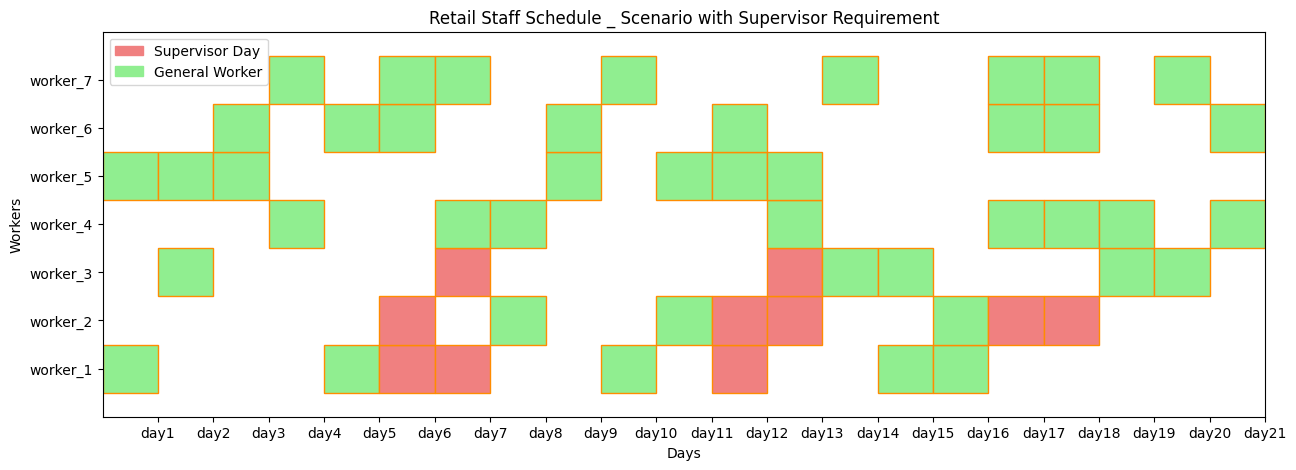


Worker Summary:
  Worker  Total Days Worked                                        Assigned Days
worker_1                8.0   day1, day5, day6, day7, day10, day12, day15, day16
worker_2                8.0 day6, day8, day11, day12, day13, day16, day17, day18
worker_3                7.0        day2, day7, day13, day14, day15, day19, day20
worker_4                8.0  day4, day7, day8, day13, day17, day18, day19, day21
worker_5                7.0          day1, day2, day3, day9, day11, day12, day13
worker_6                8.0   day3, day5, day6, day9, day12, day17, day18, day21
worker_7                8.0  day4, day6, day7, day10, day14, day17, day18, day20

Supervisor Shifts:
  Day Supervisor
 day6   worker_2
 day7   worker_3
day12   worker_2
day13   worker_3
day17   worker_2
day18   worker_2


In [33]:
# Generating the Gantt chart
def generate_gantt_diagram(model, workers, shifts, supervisor_days, buffer):
    fig, ax = plt.subplots(figsize=(15, 5))

    # Set y-axis limits
    ax.set_ylim(0, len(workers) + 1)
    ax.set_yticks(range(1, len(workers) + 1))
    ax.set_yticklabels(workers)

    # Set x-axis limits
    ax.set_xlim(0, len(shifts))
    ax.set_xticks(range(1, len(shifts) + 1))
    ax.set_xticklabels(shifts)

    # Plot worker shifts
    for i, worker in enumerate(workers, start=1):
        for j, day in enumerate(shifts):
            if model.x[worker, day].value == 1:
                facecolor = 'lightgreen'
                if day in supervisor_days and worker in supervisors:
                    facecolor = 'lightcoral'
                rect = mpatches.Rectangle((j, i - 0.5), 1, 1, facecolor=facecolor, edgecolor='darkorange')
                ax.add_patch(rect)

    # Add legend
    supervisor_patch = mpatches.Patch(color='lightcoral', label='Supervisor Day')
    general_worker_patch = mpatches.Patch(color='lightgreen', label='General Worker')
    ax.legend(handles=[supervisor_patch, general_worker_patch])

    # Set labels and title
    ax.set_xlabel('Days')
    ax.set_ylabel('Workers')
    ax.set_title('Retail Staff Schedule _ Scenario with Supervisor Requirement')

    # Save the Gantt chart as an image file
    plt.savefig(buffer, bbox_inches='tight')
    # Show the chart
    plt.show()

generate_gantt_diagram(model, workers, days, supervisor_days, 'retail_staff_schedule_scenario_with_supervisor_requirement.png')


# Generate summary report
def generate_summary_report(model, workers, days, supervisors, supervisor_days):
    summary = {
        "total_cost": pyo.value(model.objective),
        "worker_details": {},
        "supervisor_shifts": {}
    }

    for w in workers:
        total_days_worked = pyo.value(model.tot_days[w])
        assigned_days = [d for d in days if pyo.value(model.x[w, d]) == 1]
        summary["worker_details"][w] = {
            "total_days_worked": total_days_worked,
            "assigned_days": assigned_days
        }

    for d in supervisor_days:
        for w in supervisors:
            if pyo.value(model.x[w, d]) == 1:
                summary["supervisor_shifts"][d] = w

    return summary

summary_report = generate_summary_report(model, workers, days, supervisors, supervisor_days)

# Create a pandas DataFrame for the summary report
worker_summary = {
    "Worker": [],
    "Total Days Worked": [],
    "Assigned Days": []
}

for w in workers:
    worker_summary["Worker"].append(w)
    worker_summary["Total Days Worked"].append(summary_report["worker_details"][w]["total_days_worked"])
    worker_summary["Assigned Days"].append(", ".join(summary_report["worker_details"][w]["assigned_days"]))

df_worker_summary = pd.DataFrame(worker_summary)

# Supervisor shifts summary
supervisor_summary = {
    "Day": [],
    "Supervisor": []
}

for d, w in summary_report["supervisor_shifts"].items():
    supervisor_summary["Day"].append(d)
    supervisor_summary["Supervisor"].append(w)

df_supervisor_summary = pd.DataFrame(supervisor_summary)

# Display the summaries
print("\nWorker Summary:")
print(df_worker_summary.to_string(index=False))

print("\nSupervisor Shifts:")
print(df_supervisor_summary.to_string(index=False))


## 5.4 - Constraints and Objective(s) Scenario 1 + 2
*Comment the code in the next cell that defines the objectives and the constraints of the model.*<br>

### Objective Function

- **Objective:** 1 + 2

### Constraints

- **Shift Requirements:**  This constraint ensures that the required number of workers are assigned to each day.

\begin{equation}
\sum_{w \in \text{workers}} \text{model.x}[w, d] = \text{shift_limit}[d], \quad \forall d \in \text{days}
\end{equation}


- **Worker Availability:** This constraint ensures that a worker is only assigned to a day if they are available.

\begin{align*}
\text{model.x}[w, d] \leq \text{availability}[w, d], \quad \forall w \in \text{workers}, \forall d \in \text{days}
\end{align*}


- **Supervisor Requirement:** This constraint ensures that at least one supervisor is assigned to the days requiring supervision.

\begin{equation}
\sum_{w \in \text{supervisors}} \text{model.x}[w, d] = 1, \quad \forall d \in \text{supervisor_days}
\end{equation}


- **Update Total Days Worked:** This constraint updates the total days worked by each worker.

\begin{equation}
\text{tot_days}[w] = \sum_{d \in \text{days}} \text{model.x}[w, d], \quad \forall w \in \text{workers}
\end{equation}


- **Minimum Work Days Constraint:** This constraint ensures that each worker works at least a minimum number of days (5 days).

\begin{equation}
\text{tot_days}[w] \geq 5, \quad \forall w \in \text{workers}
\end{equation}


- **Consecutive Days Constraint:** This constraint ensures that a worker does not work more than 3 consecutive days.

\begin{equation}
\sum_{j=i}^{i+3} \text{model.x}[w, \text{days}[j]] \leq 3, \quad \forall w \in \text{workers}, \forall i \in \{0, \ldots, |\text{days}| - 4\}
\end{equation}

In [34]:
# Weights for the objective components
weight_cost = 0.2
weight_fairness = 0.8

# Objective function: Minimize a weighted sum of cost and the difference between max and min days worked
model.objective = pyo.Objective(
    expr=weight_cost * sum(model.tot_days[w] * model.salary[w] for w in model.workers) +
         weight_fairness * (model.max_days - model.min_days),
    sense=pyo.minimize
)

# Constraints
# Shift requirements
model.shift_requirements = pyo.ConstraintList()
for d in model.days:
    model.shift_requirements.add(sum(model.x[w, d] for w in model.workers) == model.shift_limit[d])

# Worker availability
model.worker_availability_constraint = pyo.Constraint(
    model.workers, model.days,
    rule=lambda model, w, d: model.x[w, d] <= model.availability[w, d]
)

# Supervisor requirement
model.supervisor_requirements = pyo.ConstraintList()
for d in supervisor_days:
    model.supervisor_requirements.add(sum(model.x[w, d] for w in supervisors) >= 1)

# Update total days worked
model.tot_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.tot_days[w] == sum(model.x[w, d] for d in model.days)
)

# Min and Max days worked constraints
model.max_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.max_days >= model.tot_days[w]
)

model.min_days_constraint = pyo.Constraint(
    model.workers,
    rule=lambda model, w: model.min_days <= model.tot_days[w]
)

# Minimum work days constraint
min_work_days = 5  # Minimum number of days each worker should work
model.min_work_days_constraint = pyo.ConstraintList()
for w in model.workers:
    model.min_work_days_constraint.add(model.tot_days[w] >= min_work_days)

# Add the consecutive days constraint
model.consecutive_days = pyo.ConstraintList()
for w in model.workers:
    for i in range(len(model.days) - 3):
        model.consecutive_days.add(sum(model.x[w, days[j]] for j in range(i, i + 4)) <= 3)

# Add the weekly hours limit constraint
model.weekly_hours_constraint = pyo.ConstraintList()
for w in model.workers:
    for week_start in range(0, len(model.days), 5):
        week_days = days[week_start:week_start+5]
        model.weekly_hours_constraint.add(
            sum(model.x[w, d] for d in week_days) * hours_per_shift <= weekly_hours_limit
        )

#model.cost_constraint = pyo.Constraint(
 #   expr=sum(model.tot_days[w] * model.salary[w] for w in model.workers) <= 800)

This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().
This is usually indicative of a modelling error.
To avoid this warning, use block.del_component() and block.add_component().


### 5.4.1 - Model solution
*Comment the code in the next cell that calls the functions that solve the model and stores the values of the variables.*

In [35]:
# Solve the model using the CBC solver
solver = SolverFactory('cbc')
results = solver.solve(model)

# Check results and print
if results.solver.status == pyo.SolverStatus.ok and results.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Solver terminated successfully with an optimal solution.")
    total_cost = sum(pyo.value(model.tot_days[w]) * model.salary[w] for w in model.workers)
    print("Total cost:", total_cost)

    for w in model.workers:
        days_worked = pyo.value(model.tot_days[w])
        assigned_days = [d for d in model.days if pyo.value(model.x[w, d]) == 1]
        print(f"{w}: Total days worked = {days_worked}")

else:
    print("Solver did not find an optimal solution.")
    if results.solver.termination_condition == pyo.TerminationCondition.infeasible:
        print("Model is infeasible.")
        for d in model.days:
            available_workers = sum(1 for w in model.workers if model.availability[w, d] == 1)
            print(f"{d}: Shift limit = {shift_limits[d]}, Available workers = {available_workers}")


Solver terminated successfully with an optimal solution.
Total cost: 722.0
worker_1: Total days worked = 5.0
worker_2: Total days worked = 5.0
worker_3: Total days worked = 7.0
worker_4: Total days worked = 11.0
worker_5: Total days worked = 10.0
worker_6: Total days worked = 5.0
worker_7: Total days worked = 11.0


### 5.4.2 - Analysis
*Comment the model solutions and their possible applications in the real world with respect to different scenarios.*


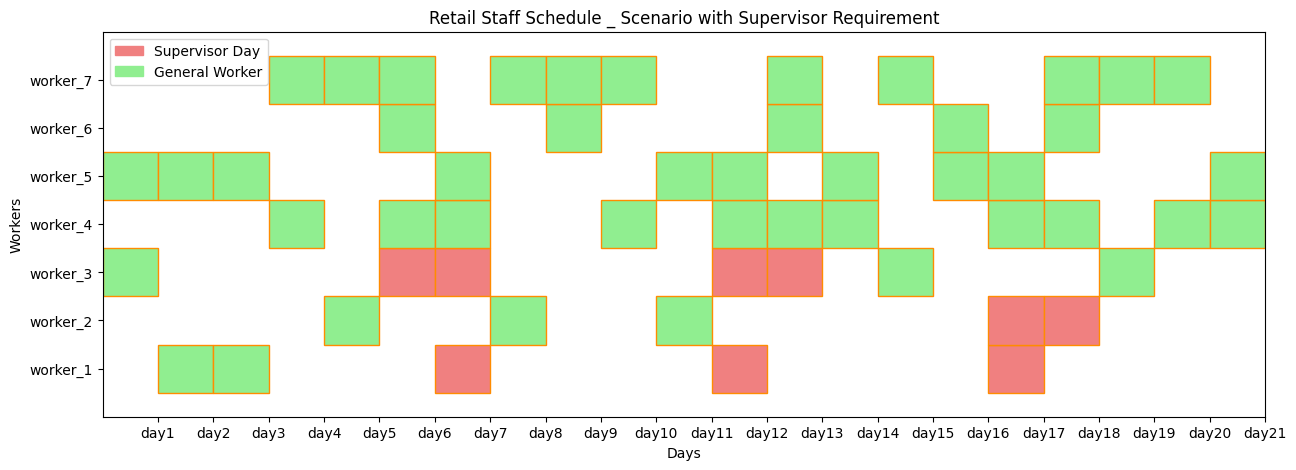


Worker Summary:
  Worker  Total Days Worked                                                            Assigned Days
worker_1                5.0                                           day2, day3, day7, day12, day17
worker_2                5.0                                          day5, day8, day11, day17, day18
worker_3                7.0                             day1, day6, day7, day12, day13, day15, day19
worker_4               11.0 day4, day6, day7, day10, day12, day13, day14, day17, day18, day20, day21
worker_5               10.0         day1, day2, day3, day7, day11, day12, day14, day16, day17, day21
worker_6                5.0                                          day6, day9, day13, day16, day18
worker_7               11.0   day4, day5, day6, day8, day9, day10, day13, day15, day18, day19, day20

Supervisor Shifts:
  Day Supervisor
 day6   worker_3
 day7   worker_3
day12   worker_3
day13   worker_3
day17   worker_2
day18   worker_2


In [36]:
# Generating the Gantt chart
def generate_gantt_diagram(model, workers, shifts, supervisor_days, buffer):
    fig, ax = plt.subplots(figsize=(15, 5))

    # Set y-axis limits
    ax.set_ylim(0, len(workers) + 1)
    ax.set_yticks(range(1, len(workers) + 1))
    ax.set_yticklabels(workers)

    # Set x-axis limits
    ax.set_xlim(0, len(shifts))
    ax.set_xticks(range(1, len(shifts) + 1))
    ax.set_xticklabels(shifts)

    # Plot worker shifts
    for i, worker in enumerate(workers, start=1):
        for j, day in enumerate(shifts):
            if model.x[worker, day].value == 1:
                facecolor = 'lightgreen'
                if day in supervisor_days and worker in supervisors:
                    facecolor = 'lightcoral'
                rect = mpatches.Rectangle((j, i - 0.5), 1, 1, facecolor=facecolor, edgecolor='darkorange')
                ax.add_patch(rect)

    # Add legend
    supervisor_patch = mpatches.Patch(color='lightcoral', label='Supervisor Day')
    general_worker_patch = mpatches.Patch(color='lightgreen', label='General Worker')
    ax.legend(handles=[supervisor_patch, general_worker_patch])

    # Set labels and title
    ax.set_xlabel('Days')
    ax.set_ylabel('Workers')
    ax.set_title('Retail Staff Schedule _ Scenario with Supervisor Requirement')

    # Save the Gantt chart as an image file
    plt.savefig(buffer, bbox_inches='tight')
    # Show the chart
    plt.show()

generate_gantt_diagram(model, workers, days, supervisor_days, 'retail_staff_schedule_scenario_with_supervisor_requirement.png')

# Generate summary report
def generate_summary_report(model, workers, days, supervisors, supervisor_days):
    summary = {
        "total_cost": pyo.value(model.objective),
        "worker_details": {},
        "supervisor_shifts": {}
    }

    for w in workers:
        total_days_worked = pyo.value(model.tot_days[w])
        assigned_days = [d for d in days if pyo.value(model.x[w, d]) == 1]
        summary["worker_details"][w] = {
            "total_days_worked": total_days_worked,
            "assigned_days": assigned_days
        }

    for d in supervisor_days:
        for w in supervisors:
            if pyo.value(model.x[w, d]) == 1:
                summary["supervisor_shifts"][d] = w

    return summary

summary_report = generate_summary_report(model, workers, days, supervisors, supervisor_days)

# Create a pandas DataFrame for the summary report
worker_summary = {
    "Worker": [],
    "Total Days Worked": [],
    "Assigned Days": []
}

for w in workers:
    worker_summary["Worker"].append(w)
    worker_summary["Total Days Worked"].append(summary_report["worker_details"][w]["total_days_worked"])
    worker_summary["Assigned Days"].append(", ".join(summary_report["worker_details"][w]["assigned_days"]))

df_worker_summary = pd.DataFrame(worker_summary)

# Supervisor shifts summary
supervisor_summary = {
    "Day": [],
    "Supervisor": []
}

for d, w in summary_report["supervisor_shifts"].items():
    supervisor_summary["Day"].append(d)
    supervisor_summary["Supervisor"].append(w)

df_supervisor_summary = pd.DataFrame(supervisor_summary)

# Display the summaries
print("\nWorker Summary:")
print(df_worker_summary.to_string(index=False))

print("\nSupervisor Shifts:")
print(df_supervisor_summary.to_string(index=False))
